# Task 4: Weather Forecast API & Time-Series EDA
Region: Cairo, Egypt | Data: NASA POWER | Year: 2024

In [1]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

## Part 1: Data Acquisition

- API used: NASA POWER
- Endpoint: https://power.larc.nasa.gov/api/temporal/daily/point
- Region: Cairo, Egypt (lat 30.0444, lon 31.2357)
- Time range: 2024-01-01 to 2024-12-31, daily
- Parameters: T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, WS2M, RH2M
- Community: RE (Renewable Energy)
- Rate limits: none, free API, no key required
- Why NASA POWER: free, no key, reliable long historical records for any location

In [2]:
url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    "?parameters=T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,WS2M,RH2M"
    "&community=RE"
    "&longitude=31.2357"
    "&latitude=30.0444"
    "&start=20240101"
    "&end=20241231"
    "&format=JSON"
)

response = requests.get(url)
response.status_code

200

In [3]:
with open("raw_weather.json", "w") as f:
    json.dump(response.json(), f)

data = response.json()
data.keys()

dict_keys(['type', 'geometry', 'properties', 'header', 'messages', 'parameters', 'times'])

In [4]:
parameters = data["properties"]["parameter"]

df = pd.DataFrame(parameters)
df = df.reset_index()
df.rename(columns={"index": "Date"}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"], format="%Y%m%d")
df.head()

,Date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,WS2M,RH2M
0,2024-01-01,14.91,20.61,9.47,0.01,1.56,77.14
1,2024-01-02,15.59,21.62,10.28,0.00,2.25,76.89
2,2024-01-03,14.39,20.92,10.22,0.00,1.51,76.49
3,2024-01-04,14.18,21.03,9.94,0.00,1.51,74.78
4,2024-01-05,13.86,21.08,8.51,0.00,1.23,67.17


In [5]:
df.to_csv("weather_cairo_2024.csv", index=False)

## Part 2: Time Series Preparation

In [6]:
df = df.sort_values("Date")
df.set_index("Date", inplace=True)
df.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,WS2M,RH2M
Date,,,,,,
2024-01-01,14.91,20.61,9.47,0.01,1.56,77.14
2024-01-02,15.59,21.62,10.28,0.00,2.25,76.89
2024-01-03,14.39,20.92,10.22,0.00,1.51,76.49
2024-01-04,14.18,21.03,9.94,0.00,1.51,74.78
2024-01-05,13.86,21.08,8.51,0.00,1.23,67.17


In [7]:
print("Rows:", len(df))
print("Inferred frequency:", pd.infer_freq(df.index))
print("Duplicate timestamps:", df.index.duplicated().sum())

full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq="D")
missing_dates = full_range.difference(df.index)
print("Missing dates count:", len(missing_dates))

Rows: 366
Inferred frequency: D
Duplicate timestamps: 0
Missing dates count: 0


In [8]:
df.isnull().sum()

,0
T2M,0
T2M_MAX,0
T2M_MIN,0
PRECTOTCORR,0
WS2M,0
RH2M,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2024-01-01 to 2024-12-31
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T2M          366 non-null    float64
 1   T2M_MAX      366 non-null    float64
 2   T2M_MIN      366 non-null    float64
 3   PRECTOTCORR  366 non-null    float64
 4   WS2M         366 non-null    float64
 5   RH2M         366 non-null    float64
dtypes: float64(6)
memory usage: 20.0 KB


### Part 2 Summary

- Datetime index set and sorted
- Frequency: daily, confirmed
- Rows: 366, correct for a leap year
- Duplicate timestamps: 0
- Missing dates: 0
- Missing values: 0 in all columns
- Units: temperature in °C, precipitation in mm/day, wind speed in m/s, humidity in %
- No cleaning needed, dataset is complete

## Part 3: Exploratory Data Analysis

### 3.1 Descriptive Overview

In [10]:
df.describe()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,WS2M,RH2M
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,22.596885,30.470601,15.757678,0.259836,2.742650,52.535437
std,7.253954,7.982594,6.207134,2.772271,0.741279,13.453540
min,8.490000,14.330000,3.320000,0.000000,0.790000,18.260000
25%,15.427500,22.865000,9.912500,0.000000,2.282500,42.317500
50%,22.450000,31.000000,15.185000,0.000000,2.730000,51.775000
75%,30.202500,38.535000,22.115000,0.000000,3.237500,62.675000
max,34.970000,45.490000,26.610000,42.540000,5.380000,84.270000


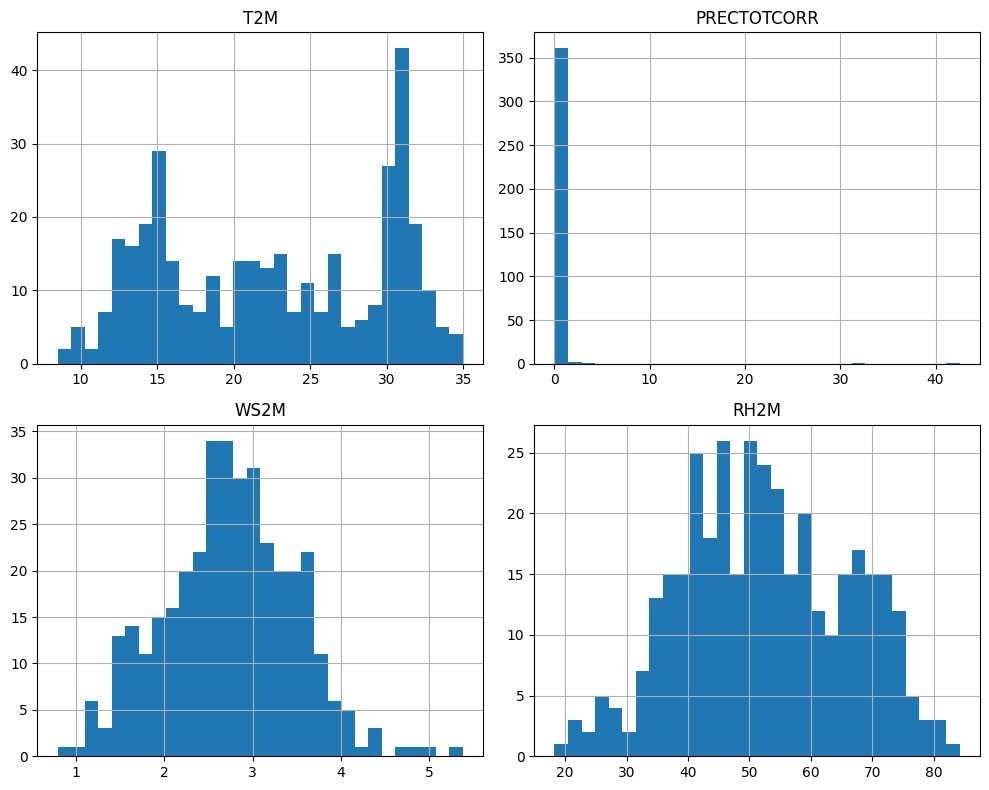

In [29]:
df[["T2M", "PRECTOTCORR", "WS2M", "RH2M"]].hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

### Distributions

- T2M: bimodal, one cluster in winter (10 to 20°C), one in summer (28 to 34°C)
- PRECTOTCORR: almost all values at 0, rain is rare
- WS2M: roughly normal, centered around 2.5 to 3 m/s
- RH2M: roughly normal, centered around 45 to 55%

### 3.2 Temporal Patterns

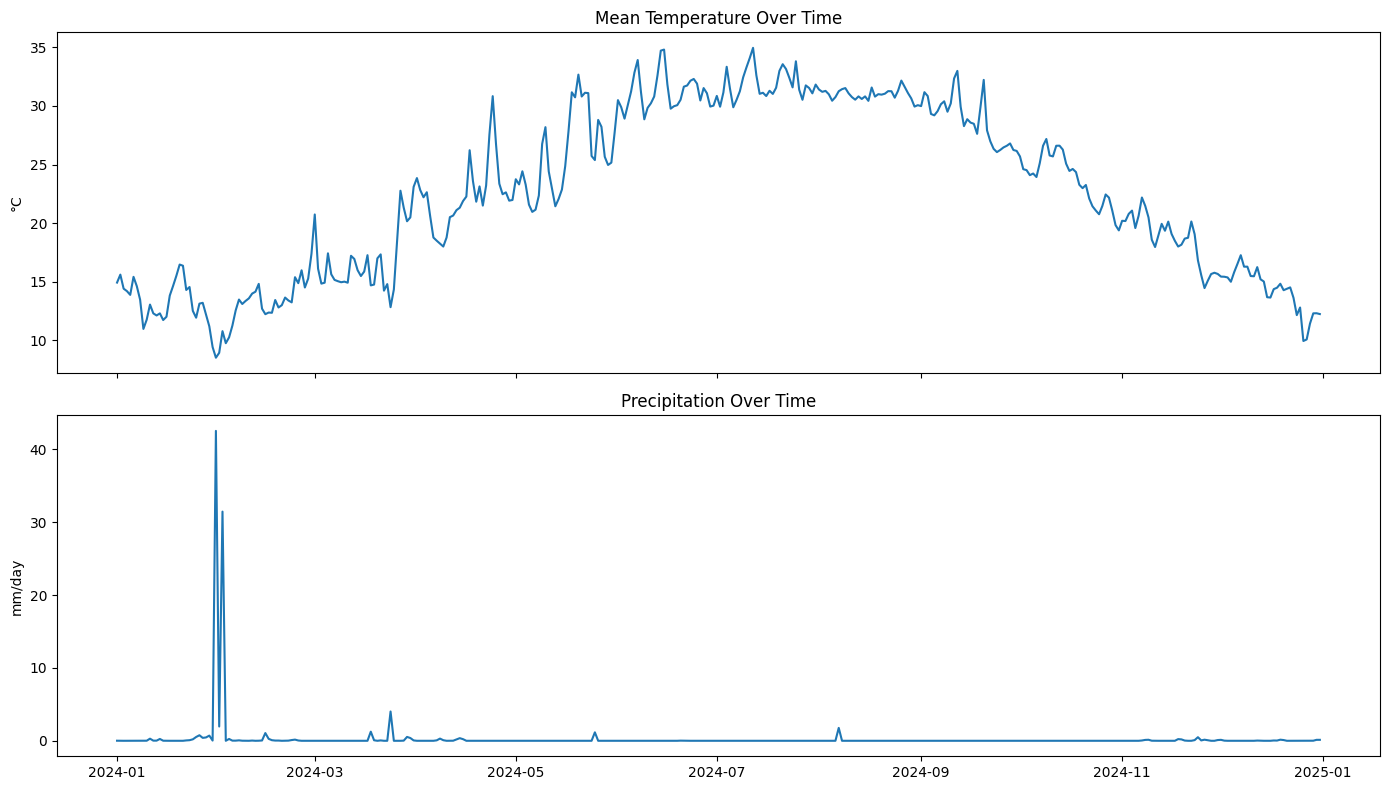

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["T2M"])
axes[0].set_title("Mean Temperature Over Time")
axes[0].set_ylabel("°C")

axes[1].plot(df.index, df["PRECTOTCORR"])
axes[1].set_title("Precipitation Over Time")
axes[1].set_ylabel("mm/day")

plt.tight_layout()
plt.show()

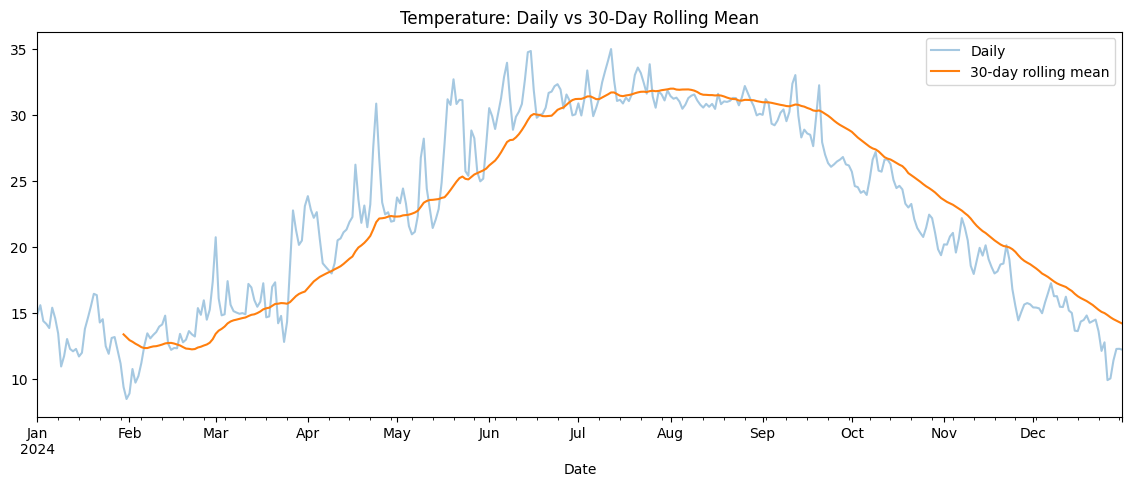

In [13]:
df["T2M"].plot(figsize=(14, 5), alpha=0.4, label="Daily")
df["T2M"].rolling(30).mean().plot(label="30-day rolling mean")
plt.title("Temperature: Daily vs 30-Day Rolling Mean")
plt.legend()
plt.show()

<Figure size 1200x500 with 0 Axes>

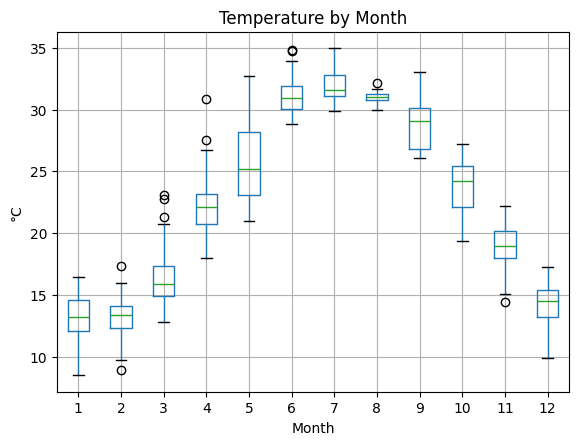

In [14]:
df["Month"] = df.index.month
df["Year"] = df.index.year
df["Weekday"] = df.index.day_name()

plt.figure(figsize=(12, 5))
df.boxplot(column="T2M", by="Month")
plt.title("Temperature by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("°C")
plt.show()

In [15]:
df.groupby("Month")["T2M"].mean()

,T2M
Month,
1,13.223226
2,13.172759
3,16.753548
4,22.298667
5,25.850645
6,31.184000
7,31.887419
8,30.998387
9,28.846667


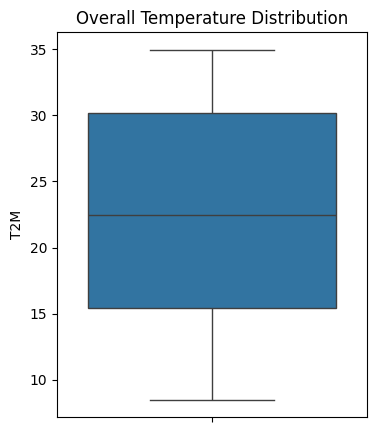

In [16]:
plt.figure(figsize=(4, 5))
sns.boxplot(y=df["T2M"])
plt.title("Overall Temperature Distribution")
plt.show()

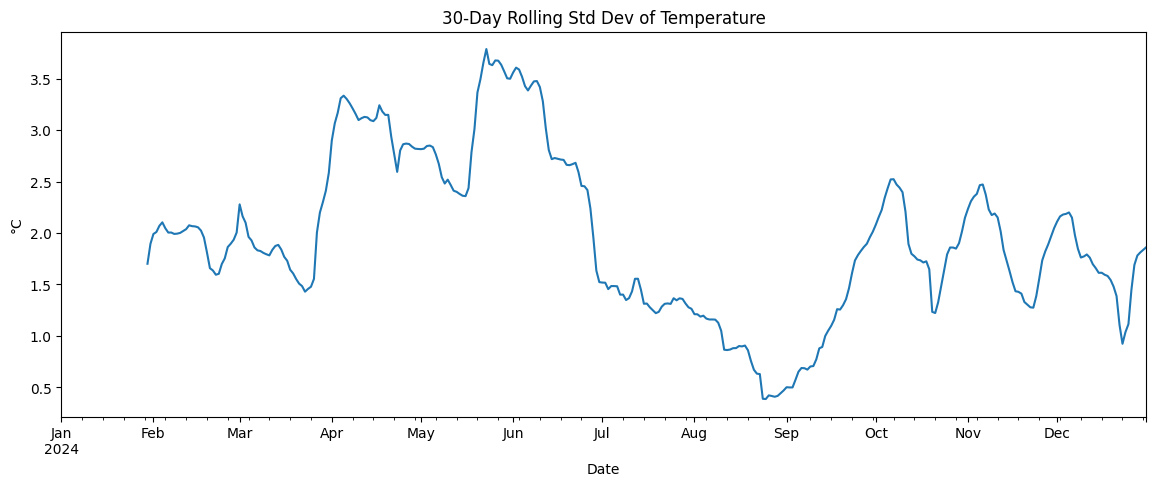

In [17]:
df["T2M"].rolling(30).std().plot(figsize=(14, 5))
plt.title("30-Day Rolling Std Dev of Temperature")
plt.ylabel("°C")
plt.show()

### Temporal Patterns Summary

- Temperature rises from about 10°C in January to 30 to 35°C in summer, then falls back down
- No long term trend, just one seasonal cycle
- July has the highest average (31.9°C), January the lowest (13.2°C)
- Volatility is highest during spring (March to June) and lowest during peak summer (August to September)

### 3.3 Decomposition and Structure

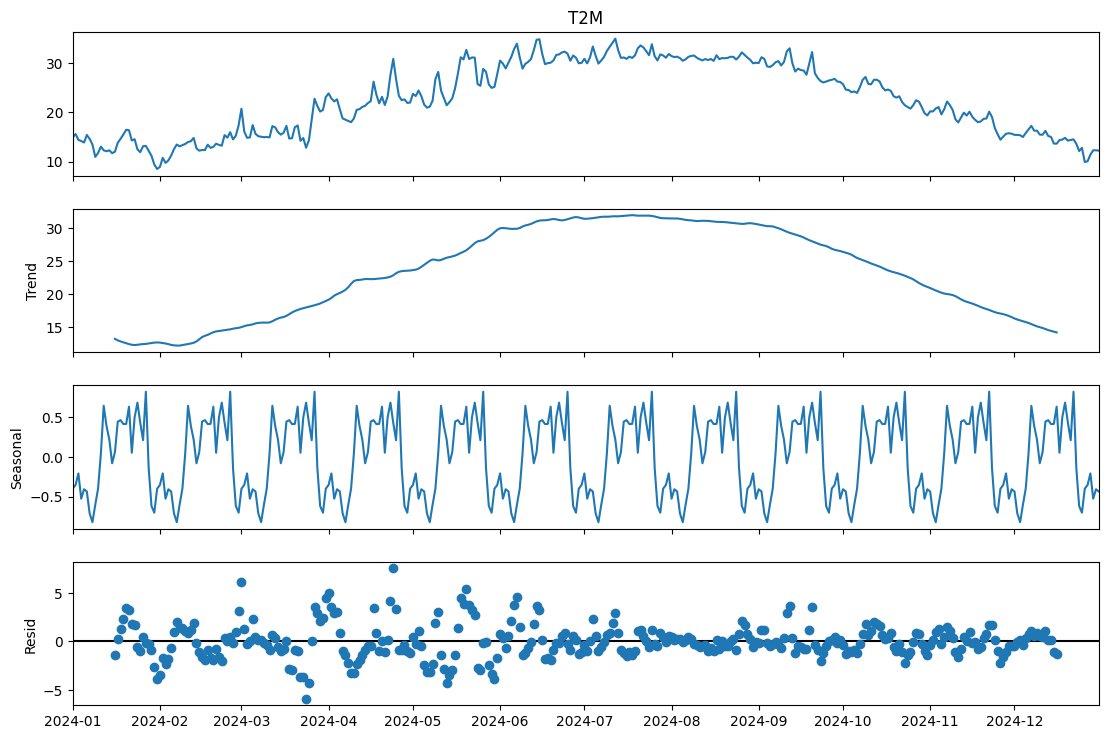

In [18]:
decomposition = seasonal_decompose(df["T2M"], model="additive", period=30)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

### Note on Decomposition

- Only 1 year of data is available (366 days)
- Full annual decomposition needs 2 full cycles, so 730 days
- Used period=30 as a workaround
- The seasonal component here reflects a 30 day pattern, not the true annual one
- The monthly boxplot above confirms the real annual seasonality instead

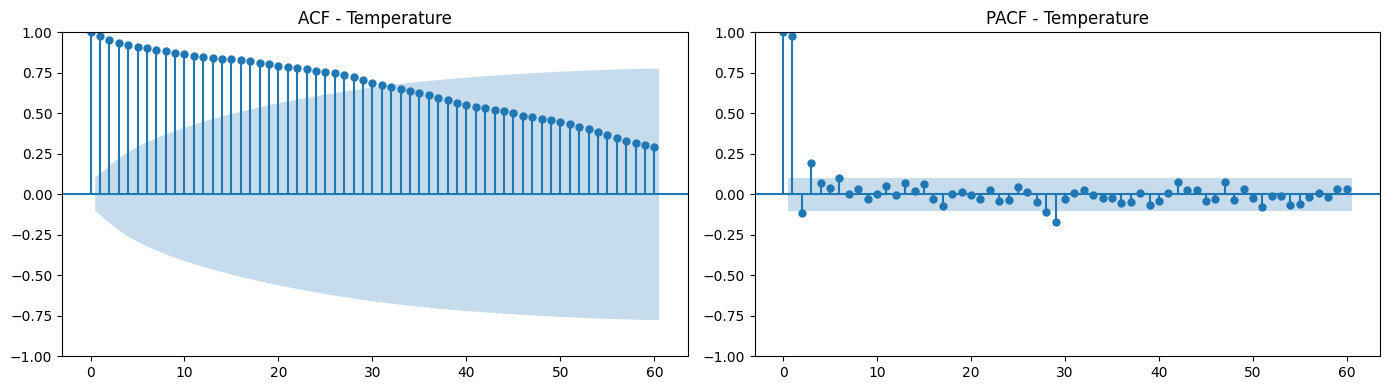

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["T2M"], lags=60, ax=axes[0])
plot_pacf(df["T2M"], lags=60, ax=axes[1])
axes[0].set_title("ACF - Temperature")
axes[1].set_title("PACF - Temperature")
plt.tight_layout()
plt.show()

In [20]:
result = adfuller(df["T2M"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.8576424186081739
p-value: 0.8016012885617975


### Stationarity Check

- ADF statistic: -0.86
- p-value: 0.80, above 0.05
- Conclusion: series is non-stationary
- Reason: strong seasonal trend means the mean is not constant over time
- ACF decays slowly and PACF cuts off after lag 1, both signs of a trending series
- Implication: ARIMA would need differencing first, tree based models and LSTM/GRU handle this more directly

### 3.4 Relationships and Anomalies

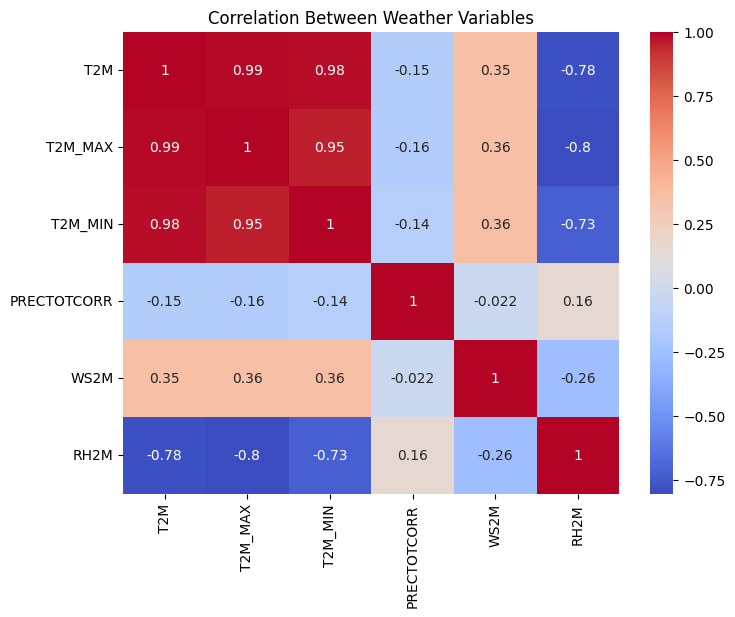

In [21]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "WS2M", "RH2M"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Weather Variables")
plt.show()

### Correlation Notes

- T2M, T2M_MAX, T2M_MIN are almost perfectly correlated, expected since they measure the same thing
- T2M and RH2M are strongly negatively correlated (about -0.78), hotter days have lower humidity
- T2M and WS2M have a weak positive correlation (about 0.35)
- PRECTOTCORR barely correlates with anything, since it is mostly 0

In [22]:
rolling_mean = df["T2M"].rolling(30, center=True).mean()
rolling_std = df["T2M"].rolling(30, center=True).std()
z_score = (df["T2M"] - rolling_mean) / rolling_std

outliers = df[abs(z_score) > 3]
print("Number of outliers:", len(outliers))
outliers[["T2M"]]

Number of outliers: 2


,T2M
Date,
2024-03-01,20.73
2024-04-24,30.84


In [23]:
precip_outliers = df[df["PRECTOTCORR"] > df["PRECTOTCORR"].quantile(0.99)]
precip_outliers[["PRECTOTCORR"]]

,PRECTOTCORR
Date,
2024-01-31,42.54
2024-02-01,1.96
2024-02-02,31.46
2024-03-24,4.02


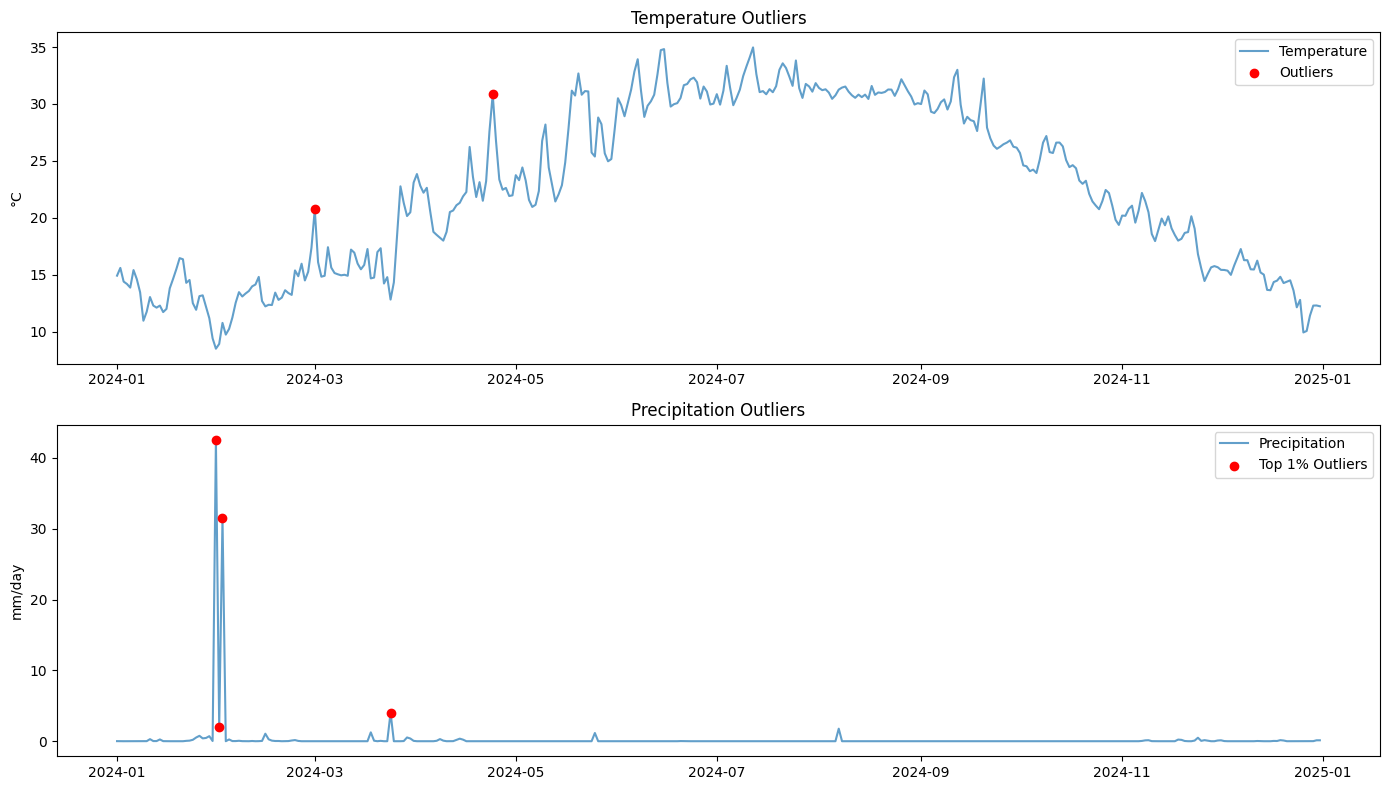

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, df["T2M"], label="Temperature", alpha=0.7)
axes[0].scatter(outliers.index, outliers["T2M"], color="red", zorder=5, label="Outliers")
axes[0].set_title("Temperature Outliers")
axes[0].set_ylabel("°C")
axes[0].legend()

axes[1].plot(df.index, df["PRECTOTCORR"], label="Precipitation", alpha=0.7)
axes[1].scatter(precip_outliers.index, precip_outliers["PRECTOTCORR"], color="red", zorder=5, label="Top 1% Outliers")
axes[1].set_title("Precipitation Outliers")
axes[1].set_ylabel("mm/day")
axes[1].legend()

plt.tight_layout()
plt.show()

### Outliers and Anomalies

Temperature outliers (rolling z-score above 3):
- March 1: 20.73°C, unusually warm for early spring
- April 24: 30.84°C, unusually warm for April
- Both look like real warm days, not sensor errors

Precipitation outliers (top 1%):
- January 31: 42.54 mm
- February 2: 31.46 mm
- These span consecutive days, consistent with a real multi day rain event

No negative rainfall or impossible temperatures found, data is clean overall

## Extra: Standout Visuals

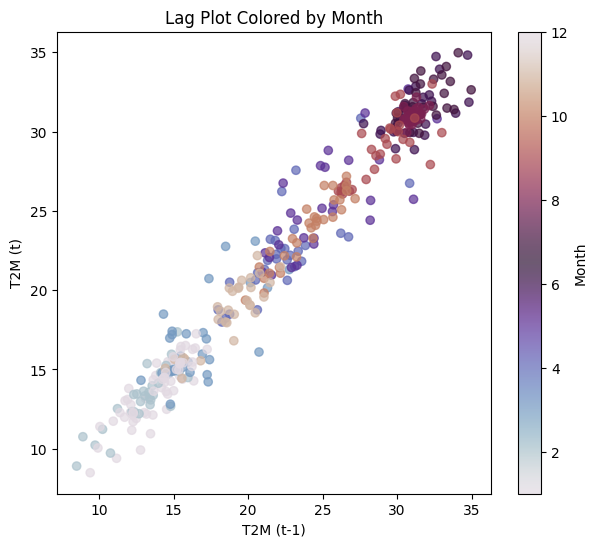

In [25]:
df["T2M_lag1"] = df["T2M"].shift(1)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(df["T2M_lag1"], df["T2M"], c=df["Month"], cmap="twilight", alpha=0.7)
plt.xlabel("T2M (t-1)")
plt.ylabel("T2M (t)")
plt.title("Lag Plot Colored by Month")
plt.colorbar(scatter, label="Month")
plt.show()

### Lag Plot Colored by Month

- Tight diagonal line shows strong day to day autocorrelation
- Color moving from light to dark and back shows the seasonal cycle
- One plot shows both autocorrelation and seasonality together

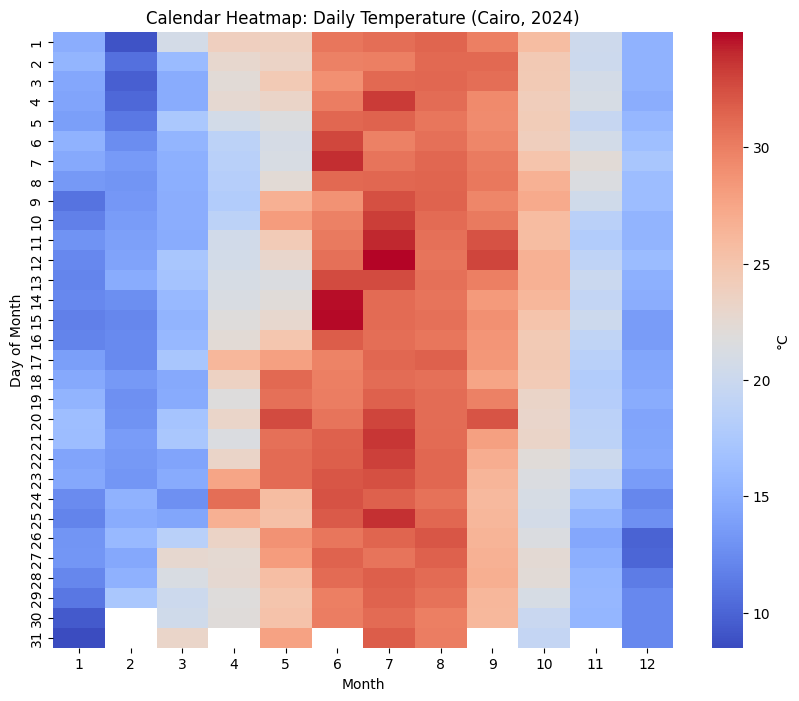

In [26]:
pivot = df.pivot_table(index=df.index.day, columns=df.index.month, values="T2M")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, cmap="coolwarm", cbar_kws={"label": "°C"})
plt.title("Calendar Heatmap: Daily Temperature (Cairo, 2024)")
plt.xlabel("Month")
plt.ylabel("Day of Month")
plt.show()

### Calendar Heatmap

- Shows the whole year's temperature pattern at a glance
- Cold edges in January, February, December
- Hot core in June, July, August, peak in mid July

## Written Summary

Region and time range: Cairo, Egypt, full year 2024, daily data.

API used: NASA POWER, chosen because it is free, needs no key, and has reliable historical data for any location.

Main patterns: temperature rises from about 10°C in January to 30 to 35°C in summer, then falls back down by December. No long term trend, just one seasonal cycle. Volatility is highest in spring and lowest in peak summer. Precipitation is rare, mostly 0, with one real rain event spanning January 31 to February 2.

Stationarity: series is non-stationary, ADF p-value is 0.80. This matches the strong seasonal trend and the slow decaying ACF.

Data quality: no missing values, no duplicates, no gaps, no impossible values. A few mild temperature outliers and the rain event were flagged but look like real weather, not errors.

Note: only 1 year of data was available, so full annual decomposition could not run. A shorter period was used as a workaround, and the monthly boxplot confirmed the true seasonality instead.